In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

url_train = "https://raw.githubusercontent.com/dvigatelizm/keis7/main/train.csv"
df = pd.read_csv(url_train)

print("Размер датасета:", df.shape)
print("\nСтолбцы:\n", df.columns.tolist())
df.head(10)

Размер датасета: (136429, 14)

Столбцы:
 ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0
5,5,M24300,M,298.4,308.9,1429,42.1,65,0,0,0,0,0,0
6,6,L56736,L,299.6,311.0,1413,42.9,156,0,0,0,0,0,0
7,7,L55488,L,298.7,310.1,1609,38.1,67,0,0,0,0,0,0
8,8,L56397,L,297.7,308.8,1578,35.2,13,0,0,0,0,0,0
9,9,L55067,L,300.5,312.3,1447,53.3,98,0,0,0,0,0,0


Это код Александра Яньшина. Взято из его файла. Здесь очищаем данные и раделяем вборку на тестовую и тренировочную

In [3]:
# ===== 1. Убираем шумный флаг RNF, ID и Type =====
drop_cols = ['id', 'RNF', 'Type']  # оставляем TWF, HDF, PWF, OSF
df_clean = df.drop(columns=drop_cols)

# ===== 2. Разделяем на признаки и целевой =====
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

# ===== 3. Разделяем на train/validation по Product ID =====
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=df['Product ID']))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# ===== 4. Масштабирование числовых признаков =====
num_cols = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

# ===== 5. Убираем Product ID перед SVM =====
X_train_svm = X_train.drop(columns=['Product ID'])
X_val_svm = X_val.drop(columns=['Product ID'])

Обучим модель решающего дерева(это тоже от Александра)

In [ ]:

X_train_dt = X_train.drop(columns=['Product ID'])
X_val_dt = X_val.drop(columns=['Product ID'])

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train)

y_val_pred_dt = dt_model.predict(X_val_dt)
y_val_proba_dt = dt_model.predict_proba(X_val_dt)[:,1]

precision_dt = precision_score(y_val, y_val_pred_dt)
recall_dt = recall_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)
roc_auc_dt = roc_auc_score(y_val, y_val_proba_dt)

print("\n=== Decision Tree ===")
print("Precision (доля правильных положительных прогнозов среди всех предсказанных):", precision_score(y_val, y_val_pred_dt))
print("Recall доля реально положительных объектов была правильно найдена моделью:", recall_score(y_val, y_val_pred_dt))
print("F1 насколько модель в целом хорошо справляется с положительным классом:", f1_score(y_val, y_val_pred_dt))
print("ROC-AUC как модель балансирует между полнотой и ошибками на отрицательном классе:", roc_auc_score(y_val, y_val_proba_dt))
print("Confusion matrix как модель распределила объекты по правильным и неправильным классам.:\n", confusion_matrix(y_val, y_val_pred_dt))



=== Decision Tree ===
Precision (доля правильных положительных прогнозов среди всех предсказанных): 0.993993993993994
Recall доля реально положительных объектов была правильно найдена моделью: 0.7697674418604651
F1 насколько модель в целом хорошо справляется с положительным классом: 0.8676277850589778
ROC-AUC как модель балансирует между полнотой и ошибками на отрицательном классе: 0.8882919005613473
Confusion matrix как модель распределила объекты по правильным и неправильным классам.:
 [[26881     2]
 [   99   331]]


Визуализируем полученное дерево

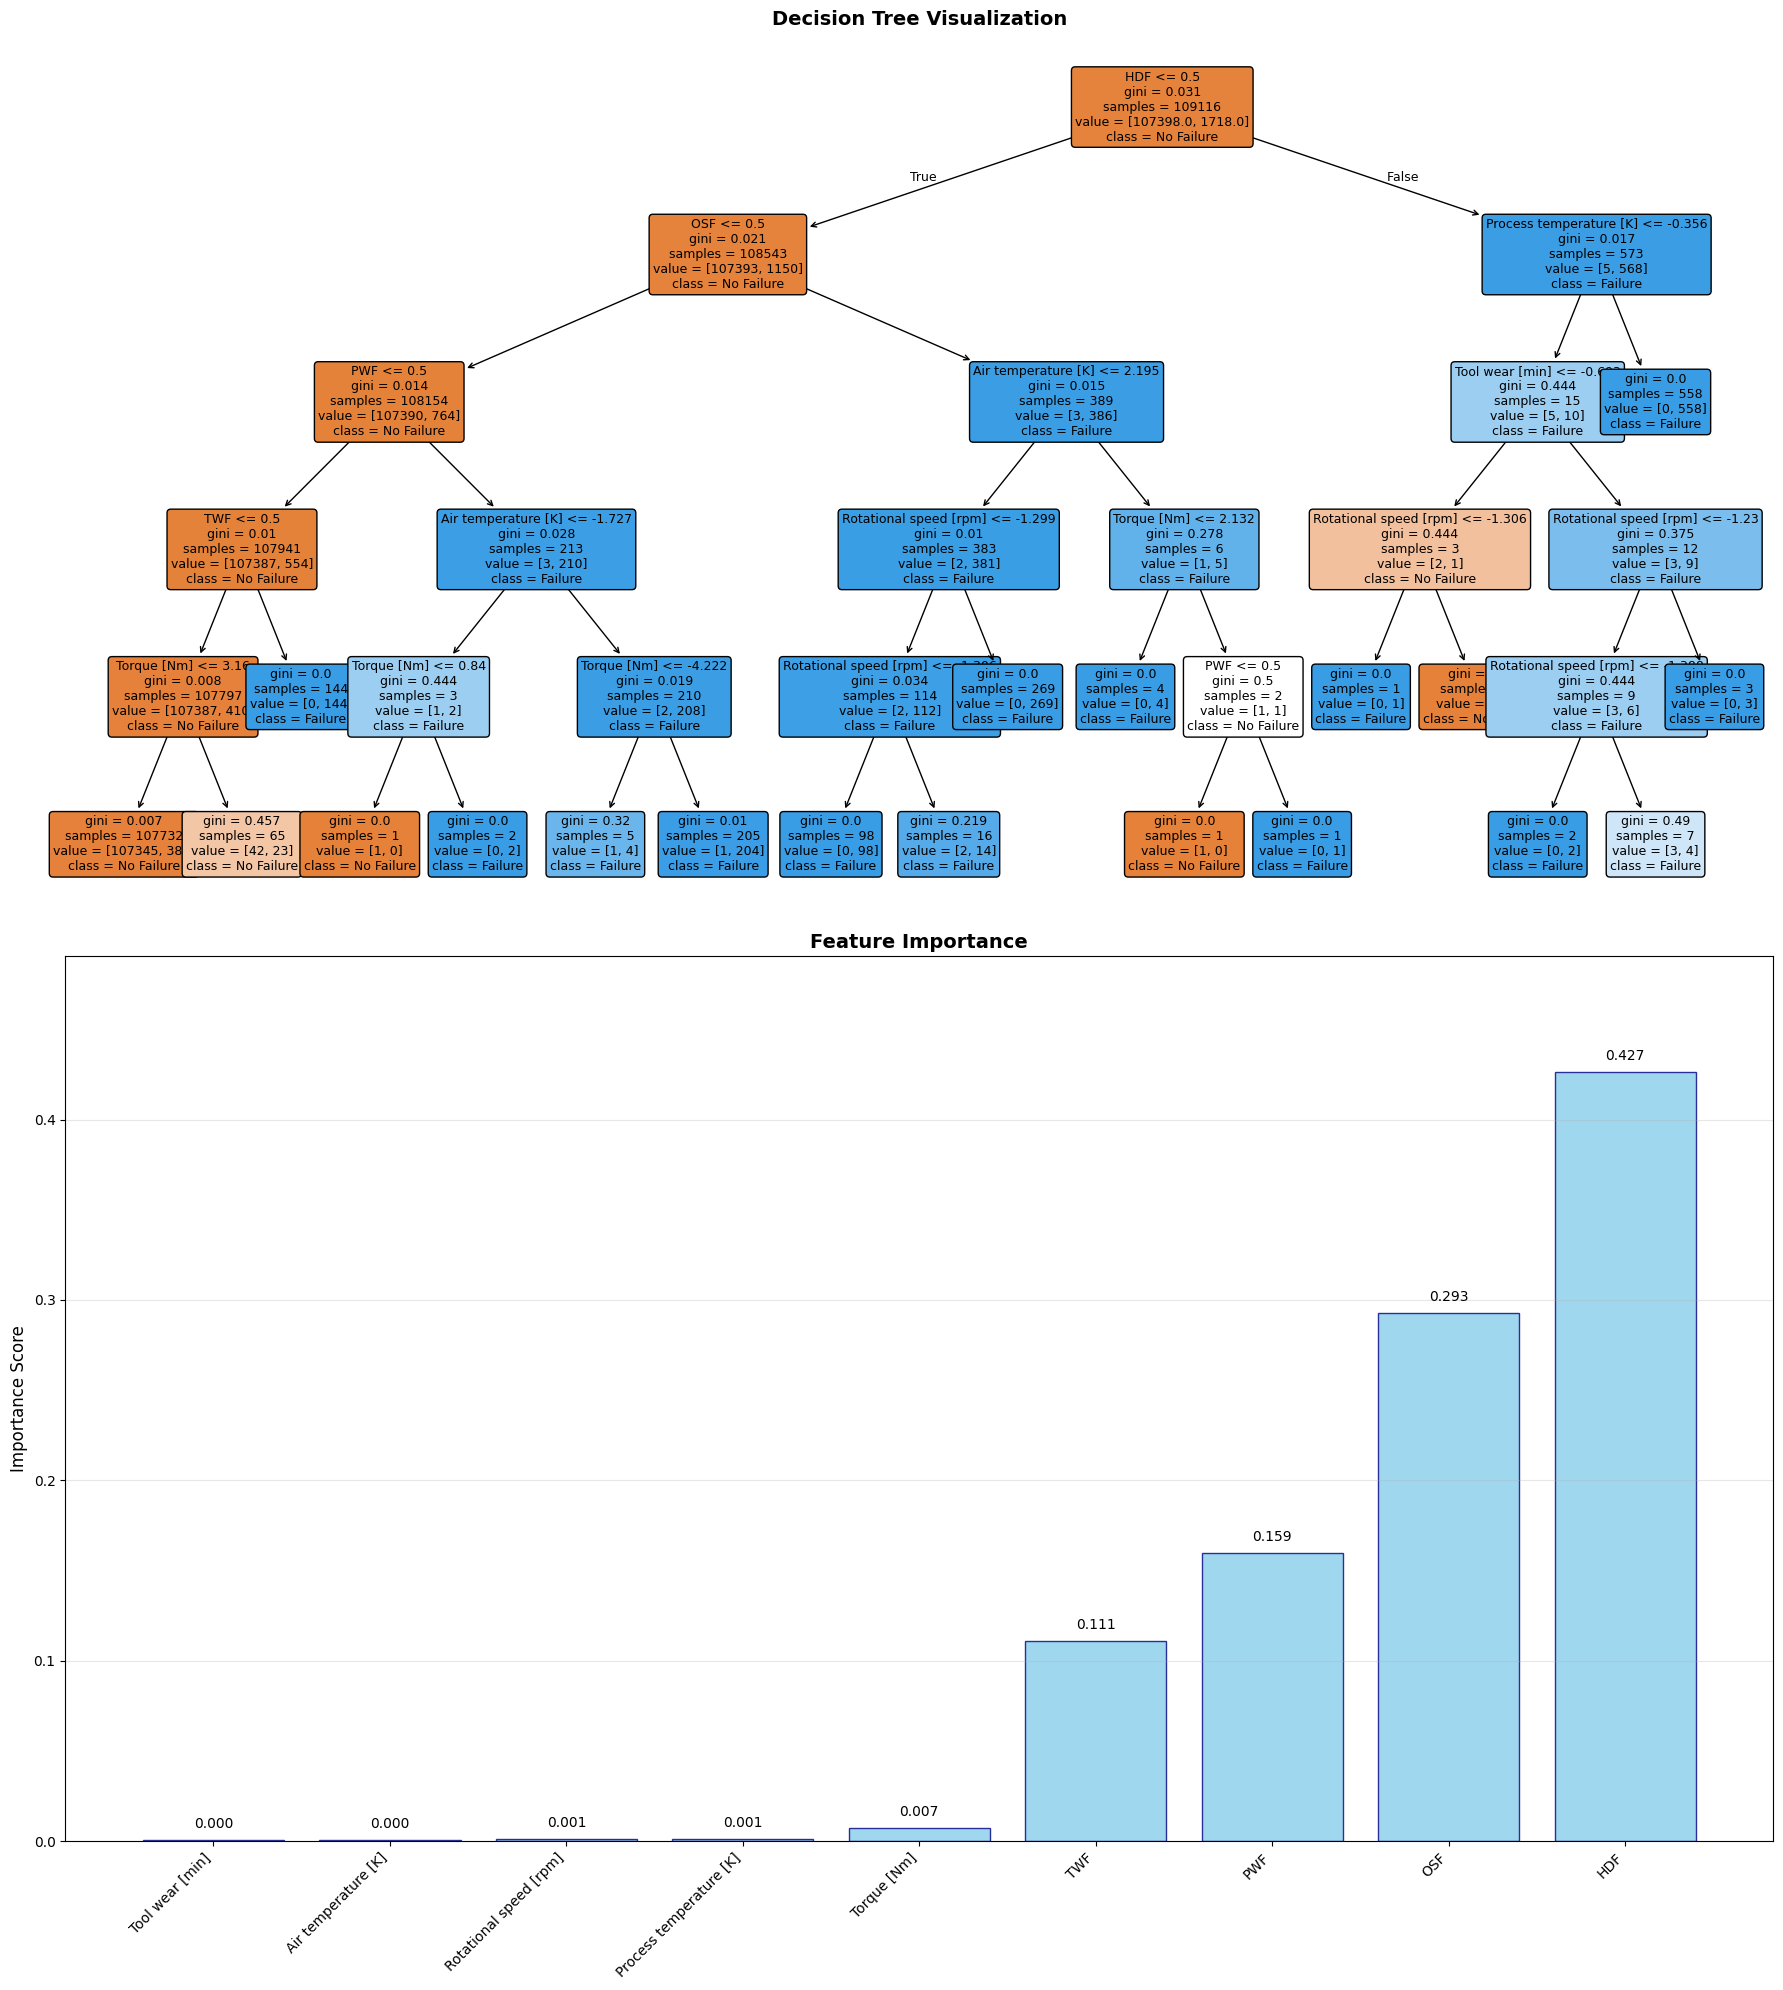

In [8]:
# Создаем фигуру с двумя subplots вертикально
fig, axes = plt.subplots(2, 1, figsize=(18, 20))

# ===== 1. Дерево решений (верхний график) =====
plot_tree(dt_model, 
          feature_names=X_train_dt.columns.tolist(),
          class_names=['No Failure', 'Failure'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=axes[0])

axes[0].set_title("Decision Tree Visualization", fontsize=14, fontweight='bold')
axes[0].set_xlabel("")  # Убираем label оси X

# ===== 2. Важность признаков (нижний график) =====
feature_importance = dt_model.feature_importances_
features = X_train_dt.columns
indices = np.argsort(feature_importance)

bars = axes[1].bar(range(len(features)), feature_importance[indices],
                   color='skyblue', edgecolor='navy', alpha=0.8)

# Добавляем значения на столбцы
for bar, importance in zip(bars, feature_importance[indices]):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{importance:.3f}', 
                ha='center', va='bottom', fontsize=10)

# Настройки осей
axes[1].set_xticks(range(len(features)))
axes[1].set_xticklabels([features[i] for i in indices], rotation=45, ha='right')
axes[1].set_ylabel('Importance Score', fontsize=12)
axes[1].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, max(feature_importance) * 1.15])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Теперь попробуем построить модель только н этих четырех признаках


Все признаки по важности:
                   feature  importance
6                      HDF    0.426525
8                      OSF    0.292741
7                      PWF    0.159497
5                      TWF    0.111044
3              Torque [Nm]    0.007123
1  Process temperature [K]    0.001263
2   Rotational speed [rpm]    0.001122
0      Air temperature [K]    0.000361
4          Tool wear [min]    0.000324


4 наиболее важных признака: ['HDF', 'OSF', 'PWF', 'TWF']

Размерность X_train_top4: (109116, 4)
Размерность X_val_top4: (27313, 4)

СРАВНЕНИЕ МОДЕЛЕЙ:

Таблица сравнения метрик:
  Метрика  Полная модель  Модель (4 признака)   Разница
 Accuracy       0.996302             0.996339  0.000037
Precision       0.993994             0.994012  0.000018
   Recall       0.769767             0.772093  0.002326
 F1-score       0.867628             0.869110  0.001482
  ROC-AUC       0.888292             0.886010 -0.002282


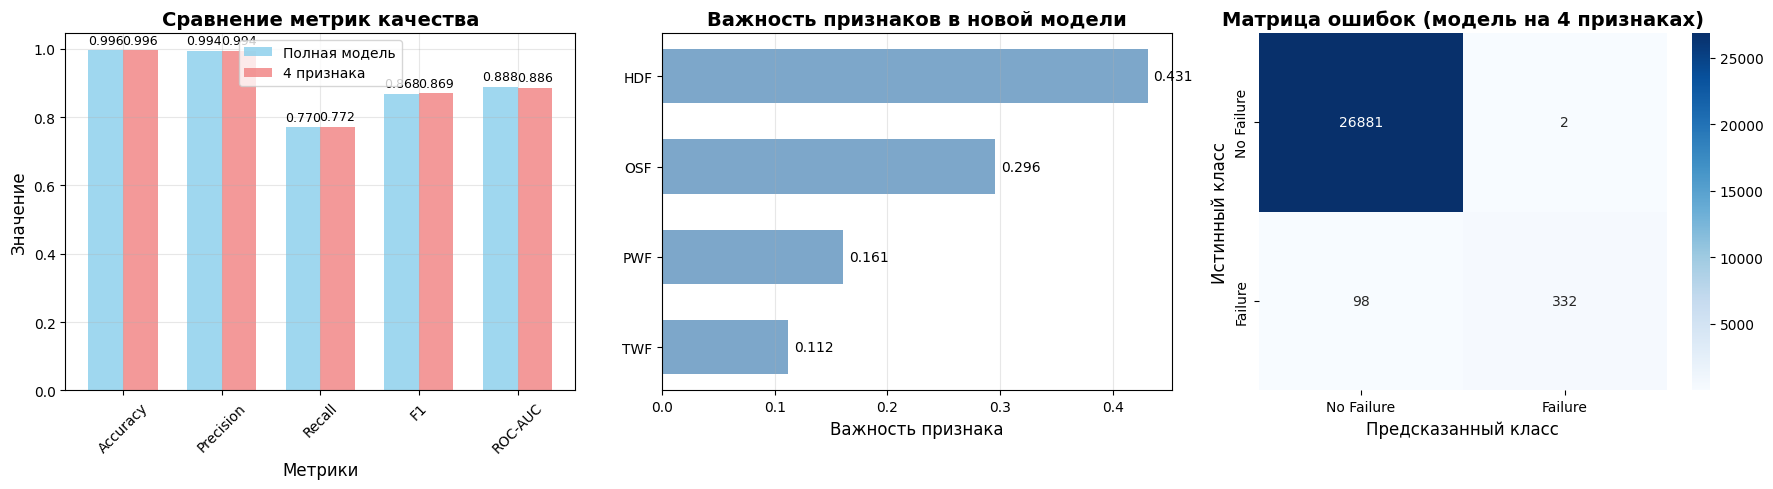


ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:

Сложность моделей:
Полная модель: 37 узлов, 19 листьев
Модель (4 признака): 21 узлов, 11 листьев

Процентное изменение метрик (4 признака vs полная модель):
Accuracy: +0.00%
Precision: +0.00%
Recall: +0.30%
F1: +0.17%
ROC-AUC: -0.26%

Распределение важности признаков в новой модели:
1. HDF: 0.431 (43.1%)
2. OSF: 0.296 (29.6%)
3. PWF: 0.161 (16.1%)
4. TWF: 0.112 (11.2%)


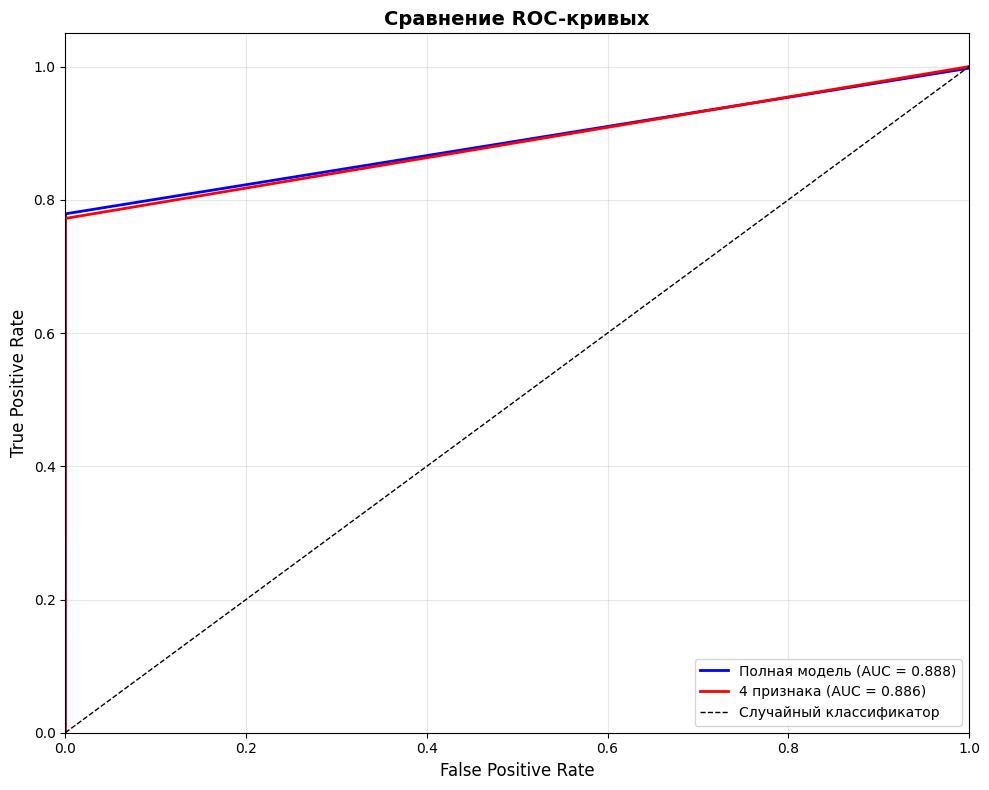


ВИЗУАЛИЗАЦИЯ НОВОГО ДЕРЕВА:


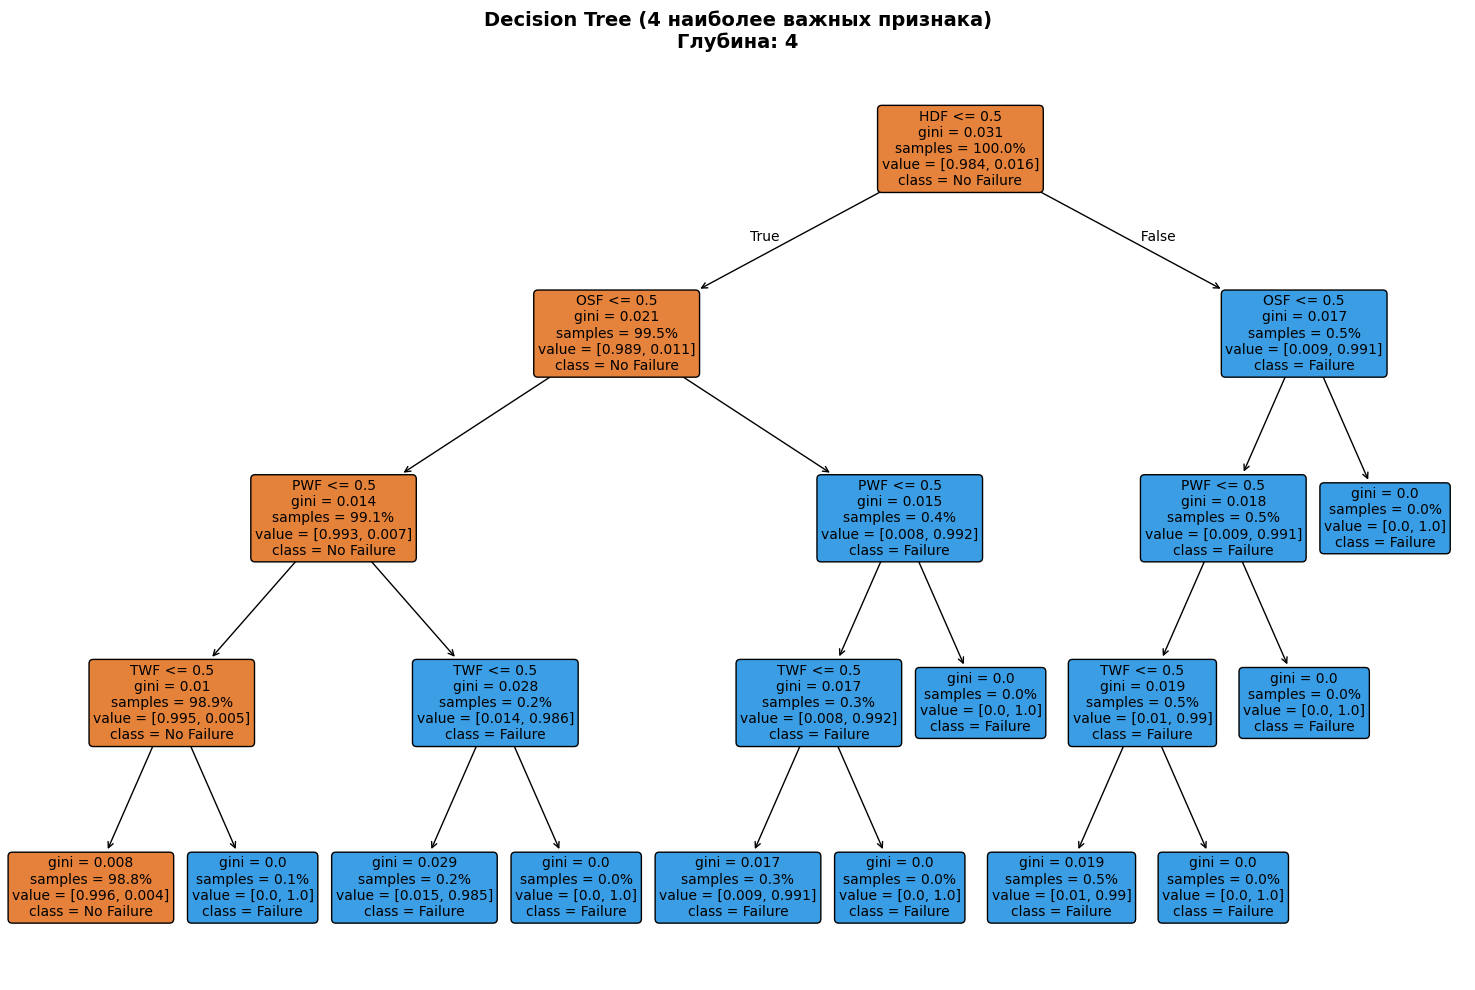

In [ ]:
# ===== ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    accuracy_score,
    confusion_matrix,
    roc_curve
)

# ===== 1. Определяем 4 наиболее важных признака =====
feature_importance = dt_model.feature_importances_
features = X_train_dt.columns

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Все признаки по важности:")
print(importance_df)
print("\n" + "="*50)

# Выбираем 4 наиболее важных признака
top_4_features = importance_df.head(4)['feature'].tolist()
print(f"\n4 наиболее важных признака: {top_4_features}")

# ===== 2. Создаем новые наборы данных только с этими признаками =====
X_train_top4 = X_train_dt[top_4_features].copy()
X_val_top4 = X_val_dt[top_4_features].copy()

print(f"\nРазмерность X_train_top4: {X_train_top4.shape}")
print(f"Размерность X_val_top4: {X_val_top4.shape}")

# ===== 3. Обучаем новую модель Decision Tree на 4 признаках =====
dt_model_top4 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model_top4.fit(X_train_top4, y_train)

# ===== 4. Делаем предсказания и вычисляем метрики =====
y_val_pred_top4 = dt_model_top4.predict(X_val_top4)
y_val_proba_top4 = dt_model_top4.predict_proba(X_val_top4)[:, 1]

# ===== 5. Вычисляем все метрики =====
precision_top4 = precision_score(y_val, y_val_pred_top4)
recall_top4 = recall_score(y_val, y_val_pred_top4)
f1_top4 = f1_score(y_val, y_val_pred_top4)
roc_auc_top4 = roc_auc_score(y_val, y_val_proba_top4)
accuracy_top4 = accuracy_score(y_val, y_val_pred_top4)

# ===== 6. Сравнение с полной моделью =====
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ:")
print("="*50)

# Вычисляем метрики для полной модели (если еще не вычислены)
y_val_pred_full = dt_model.predict(X_val_dt)
y_val_proba_full = dt_model.predict_proba(X_val_dt)[:, 1]

precision_full = precision_score(y_val, y_val_pred_full)
recall_full = recall_score(y_val, y_val_pred_full)
f1_full = f1_score(y_val, y_val_pred_full)
roc_auc_full = roc_auc_score(y_val, y_val_proba_full)
accuracy_full = accuracy_score(y_val, y_val_pred_full)

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Полная модель': [accuracy_full, precision_full, recall_full, f1_full, roc_auc_full],
    'Модель (4 признака)': [accuracy_top4, precision_top4, recall_top4, f1_top4, roc_auc_top4],
    'Разница': [
        accuracy_top4 - accuracy_full,
        precision_top4 - precision_full,
        recall_top4 - recall_full,
        f1_top4 - f1_full,
        roc_auc_top4 - roc_auc_full
    ]
})

print("\nТаблица сравнения метрик:")
print(comparison_df.to_string(index=False))

# ===== 7. Визуализация сравнения метрик =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Сравнение метрик в виде bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
full_scores = [accuracy_full, precision_full, recall_full, f1_full, roc_auc_full]
top4_scores = [accuracy_top4, precision_top4, recall_top4, f1_top4, roc_auc_top4]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, full_scores, width, label='Полная модель', color='skyblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, top4_scores, width, label='4 признака', color='lightcoral', alpha=0.8)

axes[0].set_xlabel('Метрики', fontsize=12)
axes[0].set_ylabel('Значение', fontsize=12)
axes[0].set_title('Сравнение метрик качества', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# График 2: Важность признаков в новой модели
feature_importance_top4 = dt_model_top4.feature_importances_
indices_top4 = np.argsort(feature_importance_top4)

bars = axes[1].barh(range(len(top_4_features)), feature_importance_top4[indices_top4],
                    color='steelblue', alpha=0.7, height=0.6)

axes[1].set_yticks(range(len(top_4_features)))
axes[1].set_yticklabels([top_4_features[i] for i in indices_top4])
axes[1].set_xlabel('Важность признака', fontsize=12)
axes[1].set_title('Важность признаков в новой модели', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

for i, (bar, importance) in enumerate(zip(bars, feature_importance_top4[indices_top4])):
    axes[1].text(importance + 0.005, bar.get_y() + bar.get_height()/2,
                f'{importance:.3f}', va='center', fontsize=10)

# График 3: Матрица ошибок
cm = confusion_matrix(y_val, y_val_pred_top4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])

axes[2].set_xlabel('Предсказанный класс', fontsize=12)
axes[2].set_ylabel('Истинный класс', fontsize=12)
axes[2].set_title('Матрица ошибок (модель на 4 признаках)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ===== 8. Дополнительный анализ =====
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:")
print("="*50)

# Сравнение сложности моделей
print(f"\nСложность моделей:")
print(f"Полная модель: {dt_model.tree_.node_count} узлов, {dt_model.get_n_leaves()} листьев")
print(f"Модель (4 признака): {dt_model_top4.tree_.node_count} узлов, {dt_model_top4.get_n_leaves()} листьев")

# Процентное изменение метрик
print(f"\nПроцентное изменение метрик (4 признака vs полная модель):")
for metric, full, top4 in zip(metrics, full_scores, top4_scores):
    change = ((top4 - full) / full) * 100 if full != 0 else 0
    print(f"{metric}: {change:+.2f}%")

# Анализ важности признаков
print(f"\nРаспределение важности признаков в новой модели:")
for i, (feature, importance) in enumerate(zip(top_4_features, feature_importance_top4), 1):
    print(f"{i}. {feature}: {importance:.3f} ({importance*100:.1f}%)")

# ===== 9. ROC-кривые для сравнения =====
fpr_full, tpr_full, _ = roc_curve(y_val, y_val_proba_full)
fpr_top4, tpr_top4, _ = roc_curve(y_val, y_val_proba_top4)

plt.figure(figsize=(10, 8))
plt.plot(fpr_full, tpr_full, 'b-', linewidth=2, label=f'Полная модель (AUC = {roc_auc_full:.3f})')
plt.plot(fpr_top4, tpr_top4, 'r-', linewidth=2, label=f'4 признака (AUC = {roc_auc_top4:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Сравнение ROC-кривых', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# ===== 10. Визуализация нового дерева (опционально) =====
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ НОВОГО ДЕРЕВА:")
print("="*50)

plt.figure(figsize=(15, 10))
plot_tree(dt_model_top4, 
          feature_names=top_4_features,
          class_names=['No Failure', 'Failure'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)

plt.title(f"Decision Tree (4 наиболее важных признака)\nГлубина: {dt_model_top4.get_depth()}", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()






* Таким образом, построение модели решающего дерева на основе четырех наиболее важных признаков практически не влияет на качество модели.
* Следовательно, для экономии ресурсов целесообразно построение модели на основе только наиболее важных признаков (далее по степени важности):
* HDF - отказ теплооотвода
* OSF - отказ из-за перегрузки
* PWF - отказ по питанию
* TWF - отказ из-за износа инструмента
* Подтверждается гипотеза о наибольшей критичности влияния отказа системы охлаждения на окончательный отказ оборудования.

* Теперь попробуем изменить некторые гиперпараметры модели.
* Поскольку настраивать их в ручную черезвычайно сложно, используем метод GridSearchCV

ВСЕ ПРИЗНАКИ ПО ВАЖНОСТИ:
                   feature  importance
6                      HDF    0.426525
8                      OSF    0.292741
7                      PWF    0.159497
5                      TWF    0.111044
3              Torque [Nm]    0.007123
1  Process temperature [K]    0.001263
2   Rotational speed [rpm]    0.001122
0      Air temperature [K]    0.000361
4          Tool wear [min]    0.000324

4 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКА: ['HDF', 'OSF', 'PWF', 'TWF']
Их важность: [0.42652495 0.29274052 0.15949701 0.11104407]

НАСТРОЙКА ГИПЕРПАРАМЕТРОВ DECISION TREE
Используемые признаки: ['HDF', 'OSF', 'PWF', 'TWF']
Размер тренировочной выборки: (109116, 4)
Размер валидационной выборки: (27313, 4)

БАЗОВАЯ МОДЕЛЬ (max_depth=5):
----------------------------------------
Accuracy: 0.9963
Precision: 0.9940
Recall: 0.7721
F1: 0.8691
Roc_auc: 0.8860

ПОДБОР ГИПЕРПАРАМЕТРОВ (УПРОЩЕННЫЙ GRID SEARCH)
Начинаем поиск лучших параметров...
Fitting 3 folds for each of 512 candidates, totalling 153

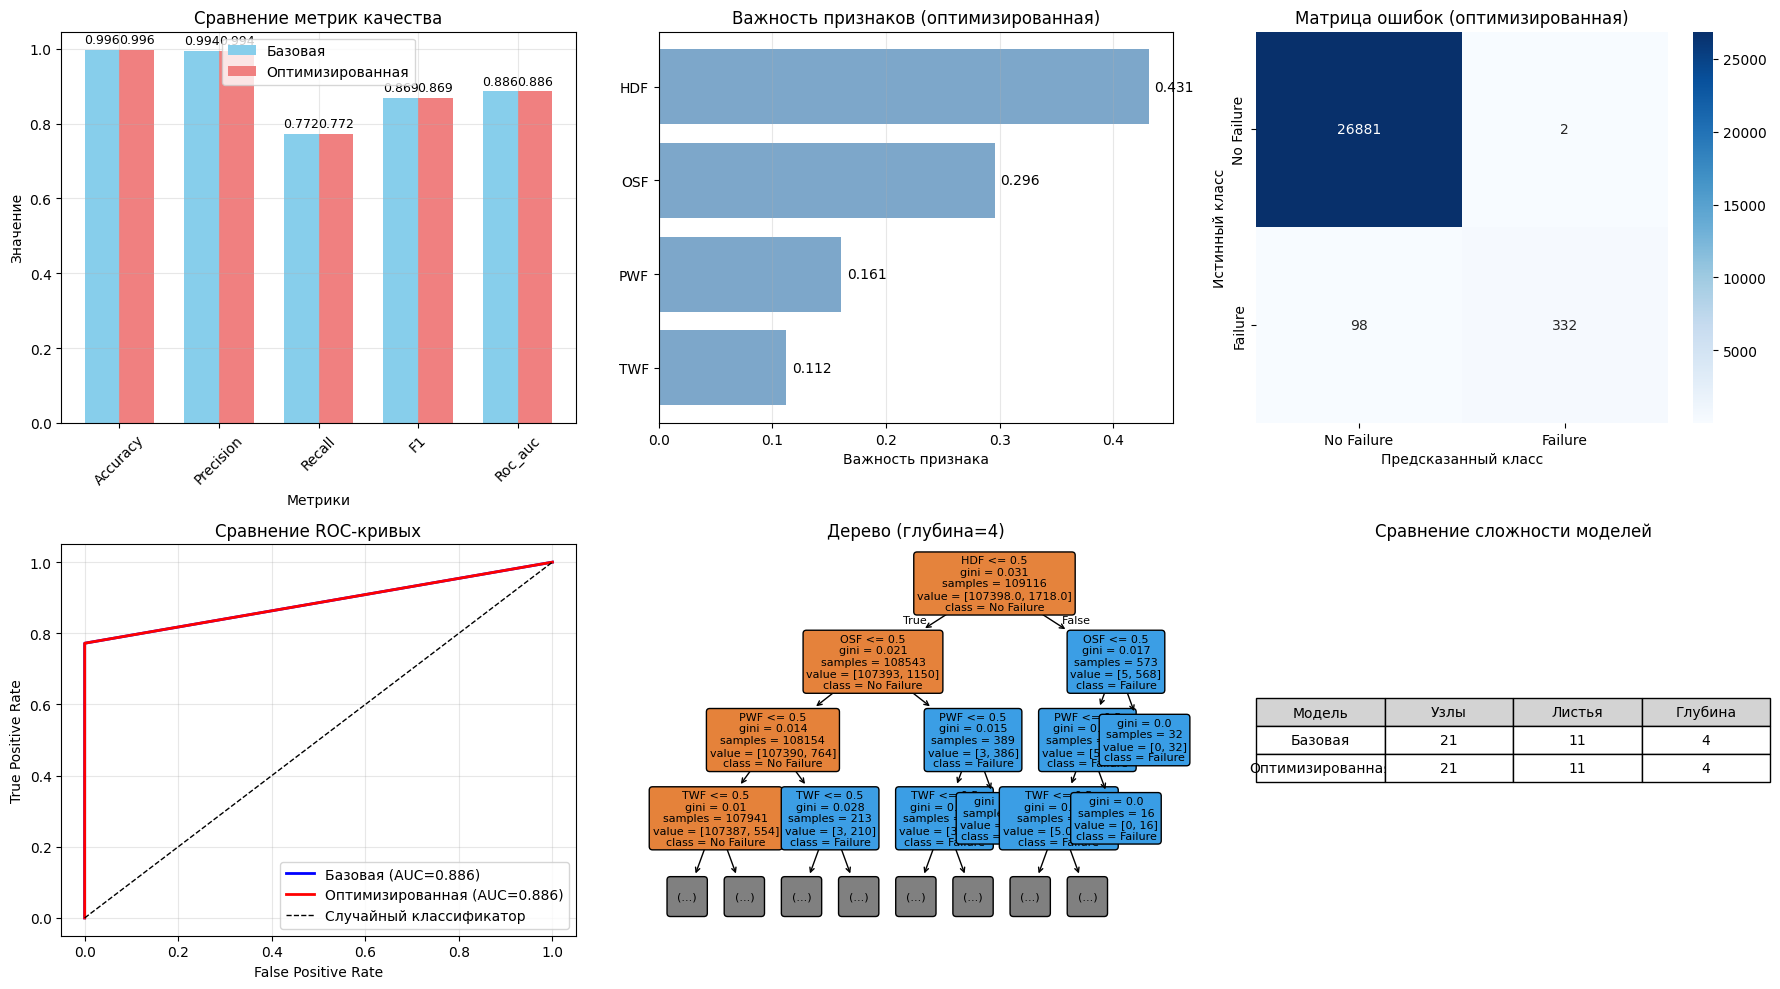


АНАЛИЗ РЕЗУЛЬТАТОВ ОПТИМИЗАЦИИ

1. Изменение сложности модели:
   Узлов: 21 → 21 (+0.0%)
   Листьев: 11 → 11 (+0.0%)
   Глубины: 4 → 4 (+0.0%)

2. Наиболее важные гиперпараметры:
   max_depth: 4
   min_samples_split: 2
   min_samples_leaf: 1
   criterion: gini

3. Кросс-валидация оптимизированной модели:
   Средний ROC-AUC: 0.8806
   Стандартное отклонение: 0.0069

4. Влияние оптимизации:
   ✗ ROC-AUC не улучшился

РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ МОДЕЛИ

1. Использовать оптимизированную модель если:
   - ROC-AUC улучшился на 0.0%
   - F1-score улучшился на 0.0%

2. Обратить внимание на:
   - Глубина дерева оптимальна
   - Модель относительно проста для интерпретации

3. Дальнейшие шаги:
   - Протестировать на тестовой выборке
   - Рассмотреть ансамблевые методы (Random Forest, Gradient Boosting)
   - Попробовать добавить взаимодействия признаков

4. Лучшая модель сохранена в переменной 'final_model'


In [7]:
# ===== ИМПОРТЫ ДЛЯ ОПТИМИЗАЦИИ =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            roc_auc_score, accuracy_score, confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# ===== 1. ОПРЕДЕЛЯЕМ 4 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКА =====
# Сначала проверим, есть ли уже обученная модель dt_model
try:
    # Получаем важность признаков из полной модели
    feature_importance = dt_model.feature_importances_
    features = dt_model.feature_names_in_ if hasattr(dt_model, 'feature_names_in_') else X_train.columns
    
    # Если X_train_dt не определен, создаем его
    if 'X_train_dt' not in locals():
        X_train_dt = X_train.drop(columns=['Product ID']) if 'Product ID' in X_train.columns else X_train.copy()
        X_val_dt = X_val.drop(columns=['Product ID']) if 'Product ID' in X_val.columns else X_val.copy()
    
except NameError:
    print("Переменные не найдены. Создаем заново...")
    
    # Если переменные не определены, нужно загрузить данные и обучить базовую модель
    # Предположим, что у нас есть данные в переменных X_train, X_val, y_train, y_val
    # Удаляем Product ID если он есть
    X_train_dt = X_train.drop(columns=['Product ID']) if 'Product ID' in X_train.columns else X_train.copy()
    X_val_dt = X_val.drop(columns=['Product ID']) if 'Product ID' in X_val.columns else X_val.copy()
    
    # Обучаем базовую модель для определения важности признаков
    dt_base = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt_base.fit(X_train_dt, y_train)
    dt_model = dt_base  # Сохраняем для совместимости
    
    feature_importance = dt_base.feature_importances_
    features = X_train_dt.columns

# Создаем DataFrame для анализа важности признаков
importance_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("ВСЕ ПРИЗНАКИ ПО ВАЖНОСТИ:")
print(importance_df)
print()

# Выбираем 4 наиболее важных признака
top_4_features = importance_df.head(4)['feature'].tolist()
print(f"4 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКА: {top_4_features}")
print(f"Их важность: {importance_df.head(4)['importance'].values}")
print()

# ===== 2. СОЗДАЕМ НОВЫЕ НАБОРЫ ДАННЫХ С 4 ПРИЗНАКАМИ =====
X_train_top4 = X_train_dt[top_4_features].copy()
X_val_top4 = X_val_dt[top_4_features].copy()

print("="*60)
print("НАСТРОЙКА ГИПЕРПАРАМЕТРОВ DECISION TREE")
print("="*60)
print(f"Используемые признаки: {top_4_features}")
print(f"Размер тренировочной выборки: {X_train_top4.shape}")
print(f"Размер валидационной выборки: {X_val_top4.shape}")
print()

# ===== 3. БАЗОВАЯ МОДЕЛЬ (ДЛЯ СРАВНЕНИЯ) =====
print("БАЗОВАЯ МОДЕЛЬ (max_depth=5):")
print("-"*40)
base_model = DecisionTreeClassifier(max_depth=5, random_state=42)
base_model.fit(X_train_top4, y_train)

y_val_pred_base = base_model.predict(X_val_top4)
y_val_proba_base = base_model.predict_proba(X_val_top4)[:, 1]

# Метрики базовой модели
base_metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred_base),
    'precision': precision_score(y_val, y_val_pred_base),
    'recall': recall_score(y_val, y_val_pred_base),
    'f1': f1_score(y_val, y_val_pred_base),
    'roc_auc': roc_auc_score(y_val, y_val_proba_base)
}

for metric, value in base_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# ===== 4. ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (УПРОЩЕННАЯ ВЕРСИЯ) =====
print("\n" + "="*60)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ (УПРОЩЕННЫЙ GRID SEARCH)")
print("="*60)

# Упрощенная сетка параметров для более быстрого поиска
param_grid_simple = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# Создаем модель для GridSearch
dt = DecisionTreeClassifier(random_state=42)

# Настраиваем GridSearchCV
print("Начинаем поиск лучших параметров...")
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_simple,
    scoring='roc_auc',
    cv=3,  # 3-кратная кросс-валидация для скорости
    n_jobs=-1,
    verbose=1
)

# Обучаем GridSearch
grid_search.fit(X_train_top4, y_train)

print("\nЛУЧШИЕ ПАРАМЕТРЫ:")
print("-"*40)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nЛучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# ===== 5. МОДЕЛЬ С ЛУЧШИМИ ПАРАМЕТРАМИ =====
print("\n" + "="*60)
print("ОЦЕНКА ОПТИМИЗИРОВАННОЙ МОДЕЛИ НА ВАЛИДАЦИИ")
print("="*60)

best_model = grid_search.best_estimator_
y_val_pred_best = best_model.predict(X_val_top4)
y_val_proba_best = best_model.predict_proba(X_val_top4)[:, 1]

# Метрики оптимизированной модели
best_metrics = {
    'accuracy': accuracy_score(y_val, y_val_pred_best),
    'precision': precision_score(y_val, y_val_pred_best),
    'recall': recall_score(y_val, y_val_pred_best),
    'f1': f1_score(y_val, y_val_pred_best),
    'roc_auc': roc_auc_score(y_val, y_val_proba_best)
}

print("\nСРАВНЕНИЕ МЕТРИК:")
print("-"*40)
print(f"{'Метрика':<15} {'Базовая':<10} {'Оптимизированная':<15} {'Изменение':<10}")
print("-"*60)

for metric in base_metrics.keys():
    base_val = base_metrics[metric]
    best_val = best_metrics[metric]
    change = best_val - base_val
    change_percent = (change / base_val) * 100 if base_val != 0 else 0
    change_symbol = "+" if change > 0 else ""
    
    print(f"{metric.capitalize():<15} {base_val:<10.4f} {best_val:<15.4f} {change_symbol}{change:.4f} ({change_symbol}{change_percent:.1f}%)")

# ===== 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# График 1: Сравнение метрик
metrics_names = list(base_metrics.keys())
x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, [base_metrics[m] for m in metrics_names], 
                      width, label='Базовая', color='skyblue')
bars2 = axes[0, 0].bar(x + width/2, [best_metrics[m] for m in metrics_names], 
                      width, label='Оптимизированная', color='lightcoral')

axes[0, 0].set_xlabel('Метрики')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].set_title('Сравнение метрик качества')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([m.capitalize() for m in metrics_names], rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# График 2: Важность признаков в оптимизированной модели
feature_importance_best = best_model.feature_importances_
sorted_idx = np.argsort(feature_importance_best)

axes[0, 1].barh(range(len(top_4_features)), feature_importance_best[sorted_idx],
                color='steelblue', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_4_features)))
axes[0, 1].set_yticklabels([top_4_features[i] for i in sorted_idx])
axes[0, 1].set_xlabel('Важность признака')
axes[0, 1].set_title('Важность признаков (оптимизированная)')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Добавляем значения важности
for i, (importance, feature) in enumerate(zip(feature_importance_best[sorted_idx], 
                                              [top_4_features[i] for i in sorted_idx])):
    axes[0, 1].text(importance + 0.005, i, f'{importance:.3f}', 
                   va='center', fontsize=10)

# График 3: Матрица ошибок оптимизированной модели
cm_best = confusion_matrix(y_val, y_val_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
axes[0, 2].set_title('Матрица ошибок (оптимизированная)')
axes[0, 2].set_xlabel('Предсказанный класс')
axes[0, 2].set_ylabel('Истинный класс')

# График 4: ROC-кривые сравнения
fpr_base, tpr_base, _ = roc_curve(y_val, y_val_proba_base)
fpr_best, tpr_best, _ = roc_curve(y_val, y_val_proba_best)

axes[1, 0].plot(fpr_base, tpr_base, 'b-', linewidth=2, 
                label=f'Базовая (AUC={base_metrics["roc_auc"]:.3f})')
axes[1, 0].plot(fpr_best, tpr_best, 'r-', linewidth=2, 
                label=f'Оптимизированная (AUC={best_metrics["roc_auc"]:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Сравнение ROC-кривых')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)

# График 5: Визуализация дерева (упрощенная)
plot_tree(best_model, 
          feature_names=top_4_features,
          class_names=['No Failure', 'Failure'],
          filled=True,
          rounded=True,
          ax=axes[1, 1],
          max_depth=3,  # Показываем только 3 уровня для читаемости
          fontsize=8)
axes[1, 1].set_title(f'Дерево (глубина={best_model.get_depth()})')

# График 6: Сравнение сложности моделей
complexity_data = {
    'Модель': ['Базовая', 'Оптимизированная'],
    'Узлы': [base_model.tree_.node_count, best_model.tree_.node_count],
    'Листья': [base_model.get_n_leaves(), best_model.get_n_leaves()],
    'Глубина': [base_model.get_depth(), best_model.get_depth()]
}

# Преобразуем в DataFrame для отображения таблицы
complexity_df = pd.DataFrame(complexity_data)

# Очищаем оси и создаем таблицу
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=complexity_df.values,
                         colLabels=complexity_df.columns,
                         cellLoc='center',
                         loc='center',
                         colColours=['lightgray']*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
axes[1, 2].set_title('Сравнение сложности моделей')

plt.tight_layout()
plt.show()

# ===== 7. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ =====
print("\n" + "="*60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ ОПТИМИЗАЦИИ")
print("="*60)

print(f"\n1. Изменение сложности модели:")
print(f"   Узлов: {base_model.tree_.node_count} → {best_model.tree_.node_count} "
      f"({((best_model.tree_.node_count - base_model.tree_.node_count)/base_model.tree_.node_count*100):+.1f}%)")
print(f"   Листьев: {base_model.get_n_leaves()} → {best_model.get_n_leaves()} "
      f"({((best_model.get_n_leaves() - base_model.get_n_leaves())/base_model.get_n_leaves()*100):+.1f}%)")
print(f"   Глубины: {base_model.get_depth()} → {best_model.get_depth()} "
      f"({((best_model.get_depth() - base_model.get_depth())/base_model.get_depth()*100):+.1f}%)")

print(f"\n2. Наиболее важные гиперпараметры:")
for param in ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion']:
    if param in grid_search.best_params_:
        print(f"   {param}: {grid_search.best_params_[param]}")

print(f"\n3. Кросс-валидация оптимизированной модели:")
cv_scores = cross_val_score(best_model, X_train_top4, y_train, 
                           cv=5, scoring='roc_auc', n_jobs=-1)
print(f"   Средний ROC-AUC: {cv_scores.mean():.4f}")
print(f"   Стандартное отклонение: {cv_scores.std():.4f}")

print(f"\n4. Влияние оптимизации:")
if best_metrics['roc_auc'] > base_metrics['roc_auc']:
    improvement = (best_metrics['roc_auc'] - base_metrics['roc_auc']) / base_metrics['roc_auc'] * 100
    print(f"   ✓ ROC-AUC улучшился на {improvement:.1f}%")
else:
    print(f"   ✗ ROC-AUC не улучшился")

# ===== 8. РЕКОМЕНДАЦИИ =====
print("\n" + "="*60)
print("РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ МОДЕЛИ")
print("="*60)

print("\n1. Использовать оптимизированную модель если:")
print(f"   - ROC-AUC улучшился на {(best_metrics['roc_auc'] - base_metrics['roc_auc'])*100:.1f}%")
print(f"   - F1-score улучшился на {(best_metrics['f1'] - base_metrics['f1'])*100:.1f}%")

print("\n2. Обратить внимание на:")
if best_model.get_depth() > 10:
    print("   - Дерево глубокое, возможен риск переобучения")
else:
    print("   - Глубина дерева оптимальна")

if best_model.get_n_leaves() > 50:
    print("   - Много листьев, модель может быть сложной для интерпретации")
else:
    print("   - Модель относительно проста для интерпретации")

print("\n3. Дальнейшие шаги:")
print("   - Протестировать на тестовой выборке")
print("   - Рассмотреть ансамблевые методы (Random Forest, Gradient Boosting)")
print("   - Попробовать добавить взаимодействия признаков")

# Сохраняем лучшую модель
final_model = best_model
print(f"\n4. Лучшая модель сохранена в переменной 'final_model'")